# Evaluating the Best Model in Multiple Linear Regression

## Objective
Using the **advertising.csv** dataset, we will:
1. Detect and handle outliers that may impact model performance
2. Compare model performance using 60/40 and 90/10 train-test splits
3. Build multiple linear regression models by dropping one feature at a time
4. Conclude which combination of features performs best

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('advertising.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Basic statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nData types:\n{df.dtypes}")

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


---
## 2. Outlier Detection and Handling

### 2.1 Visualizing Outliers with Box Plots

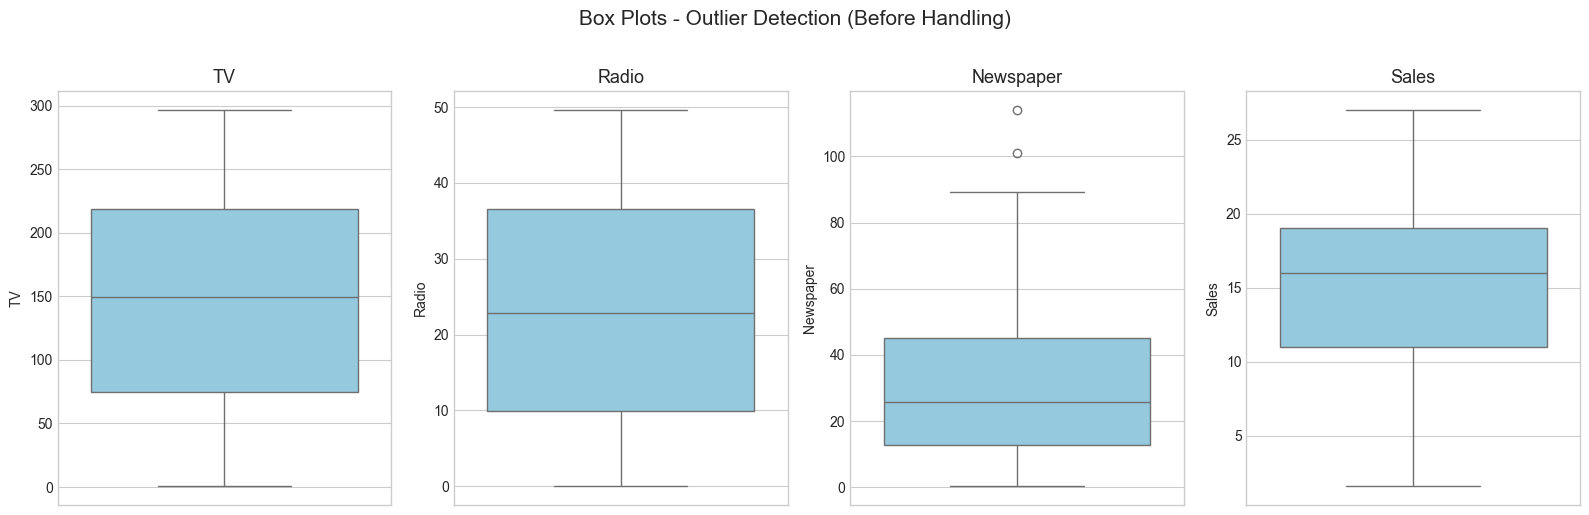

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}', fontsize=13)
fig.suptitle('Box Plots - Outlier Detection (Before Handling)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Detecting Outliers Using IQR Method

In [6]:
def detect_outliers_iqr(dataframe, column):
    """Detect outliers using the IQR method."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier Detection Summary (IQR Method)")
print("=" * 50)
for col in df.columns:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outlier(s) | Bounds: [{lb:.2f}, {ub:.2f}]")
    if len(outliers) > 0:
        print(f"  Outlier values: {sorted(outliers[col].values)}")

Outlier Detection Summary (IQR Method)
TV: 0 outlier(s) | Bounds: [-142.30, 435.50]
Radio: 0 outlier(s) | Bounds: [-29.85, 76.35]
Newspaper: 2 outlier(s) | Bounds: [-35.78, 93.62]
  Outlier values: [np.float64(100.9), np.float64(114.0)]
Sales: 0 outlier(s) | Bounds: [-1.08, 31.12]


### 2.3 Baseline Model — Before Outlier Handling

Let's first build a baseline Multiple Linear Regression model **before** handling outliers to measure the impact.

In [7]:
def evaluate_model(X_train, X_test, y_train, y_test, label=""):
    """Train a Linear Regression model and return evaluation metrics."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"--- {label} ---")
    print(f"  R² Score : {r2:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  MAE      : {mae:.4f}")
    print()
    
    return {'Label': label, 'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'Model': model}

In [8]:
# Baseline model (before outlier handling) with 80/20 split
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_result = evaluate_model(X_train, X_test, y_train, y_test, label="Baseline (Before Outlier Handling)")

--- Baseline (Before Outlier Handling) ---
  R² Score : 0.9059
  MSE      : 2.9078
  RMSE     : 1.7052
  MAE      : 1.2748



### 2.4 Handling Outliers — Capping (Winsorization)

We cap outliers at the IQR boundaries (lower and upper bounds) to reduce their extreme influence while retaining the data points.

In [9]:
def cap_outliers_iqr(dataframe, column):
    """Cap outliers using the IQR method (Winsorization)."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

# Create a copy and handle outliers
df_clean = df.copy()
for col in df_clean.columns:
    df_clean = cap_outliers_iqr(df_clean, col)

print(f"Original shape: {df.shape}")
print(f"Cleaned  shape: {df_clean.shape}")

Original shape: (200, 4)
Cleaned  shape: (200, 4)


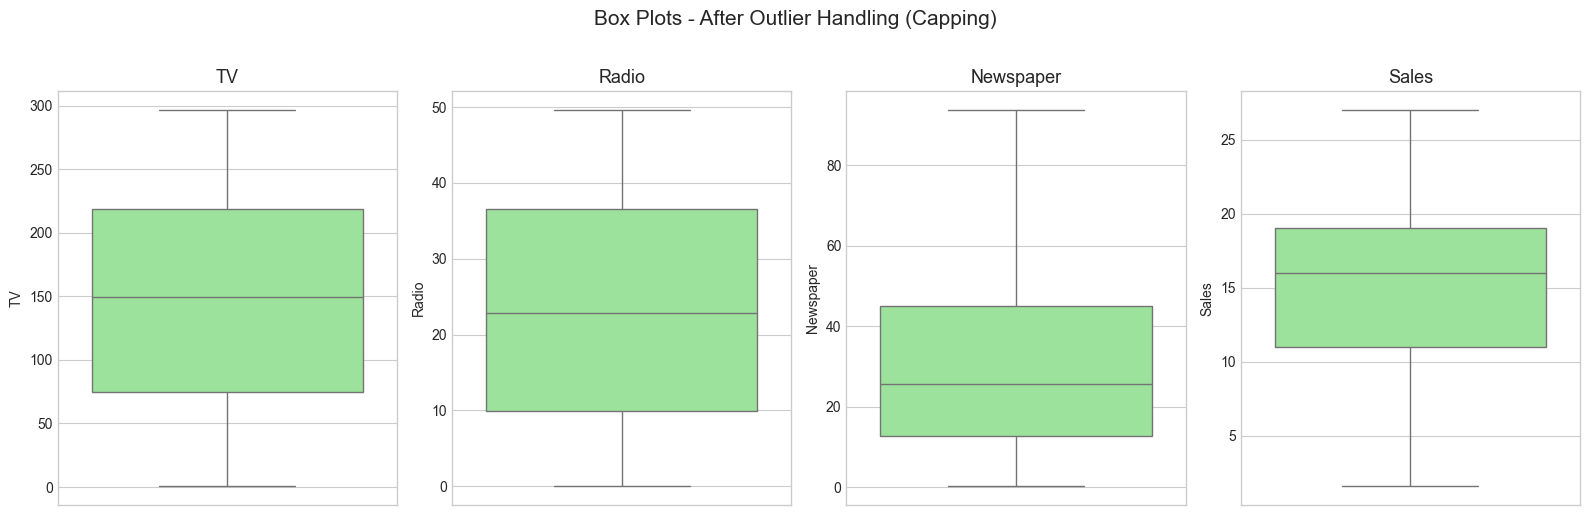

In [10]:
# Verify outliers are handled
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(df_clean.columns):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col}', fontsize=13)
fig.suptitle('Box Plots - After Outlier Handling (Capping)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Model After Outlier Handling

In [11]:
X_clean = df_clean[['TV', 'Radio', 'Newspaper']]
y_clean = df_clean['Sales']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

clean_result = evaluate_model(X_train_c, X_test_c, y_train_c, y_test_c, label="After Outlier Handling (Capping)")

--- After Outlier Handling (Capping) ---
  R² Score : 0.9058
  MSE      : 2.9107
  RMSE     : 1.7061
  MAE      : 1.2735



In [12]:
# Compare before and after
comparison_outlier = pd.DataFrame([
    {k: v for k, v in baseline_result.items() if k != 'Model'},
    {k: v for k, v in clean_result.items() if k != 'Model'}
])
comparison_outlier = comparison_outlier.set_index('Label')
print("Comparison: Before vs After Outlier Handling")
comparison_outlier

Comparison: Before vs After Outlier Handling


,R2,MSE,RMSE,MAE
Label,,,,
Baseline (Before Outlier Handling),0.905901,2.907757,1.705215,1.274826
After Outlier Handling (Capping),0.905805,2.910741,1.706090,1.273454


### Observation — Outlier Handling

After detecting and capping outliers using the IQR method, we compare the model performance. The metrics (R², MSE, RMSE, MAE) indicate whether outlier handling improved or worsened the model. Outliers in advertising spend or sales can disproportionately affect the regression coefficients, so handling them helps create a more robust and generalizable model.

---
## 3. Data Split Comparison: 60/40 vs 90/10

We will use the **cleaned dataset** (after outlier handling) for the split comparison.

In [13]:
# 60/40 Split
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X_clean, y_clean, test_size=0.40, random_state=42
)
result_60_40 = evaluate_model(X_train_60, X_test_60, y_train_60, y_test_60, label="60/40 Split")

# 90/10 Split
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X_clean, y_clean, test_size=0.10, random_state=42
)
result_90_10 = evaluate_model(X_train_90, X_test_90, y_train_90, y_test_90, label="90/10 Split")

--- 60/40 Split ---
  R² Score : 0.9015
  MSE      : 2.7171
  RMSE     : 1.6484
  MAE      : 1.2279

--- 90/10 Split ---
  R² Score : 0.9125
  MSE      : 2.8609
  RMSE     : 1.6914
  MAE      : 1.4052



In [14]:
# Compare splits
comparison_splits = pd.DataFrame([
    {k: v for k, v in result_60_40.items() if k != 'Model'},
    {k: v for k, v in result_90_10.items() if k != 'Model'}
])
comparison_splits = comparison_splits.set_index('Label')
print("Comparison: 60/40 vs 90/10 Train-Test Split")
comparison_splits

Comparison: 60/40 vs 90/10 Train-Test Split


,R2,MSE,RMSE,MAE
Label,,,,
60/40 Split,0.901453,2.717118,1.648368,1.227915
90/10 Split,0.912465,2.860891,1.691417,1.405209


### Observation — Train-Test Split Comparison

- **60/40 Split**: Uses less training data (60%), so the model has fewer samples to learn from, which may result in slightly lower performance but tests on a larger portion of the data.
- **90/10 Split**: Uses more training data (90%), so the model can learn more patterns, which generally leads to better training performance. However, testing on only 10% of the data may give less reliable evaluation metrics.

The model with a **higher R²** and **lower error metrics (MSE, RMSE, MAE)** is considered the better performing split. Generally, the 90/10 split tends to perform better if the dataset is small, as the model benefits from more training data.

---
## 4. Feature Combination Analysis — Dropping One Feature at a Time

We build three Multiple Linear Regression models, each using a different pair of features (dropping one feature at a time), and compare their performance.

We use an **80/20 split** on the cleaned data for a fair comparison.

### 4.1 Model 1: TV + Radio → Sales (Dropping Newspaper)

In [15]:
X1 = df_clean[['TV', 'Radio']]
y1 = df_clean['Sales']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
result_tv_radio = evaluate_model(X1_train, X1_test, y1_train, y1_test, label="TV + Radio (Drop Newspaper)")

--- TV + Radio (Drop Newspaper) ---
  R² Score : 0.9079
  MSE      : 2.8466
  RMSE     : 1.6872
  MAE      : 1.2670



### 4.2 Model 2: TV + Newspaper → Sales (Dropping Radio)

In [16]:
X2 = df_clean[['TV', 'Newspaper']]
y2 = df_clean['Sales']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
result_tv_news = evaluate_model(X2_train, X2_test, y2_train, y2_test, label="TV + Newspaper (Drop Radio)")

--- TV + Newspaper (Drop Radio) ---
  R² Score : 0.7933
  MSE      : 6.3881
  RMSE     : 2.5275
  MAE      : 1.9333



### 4.3 Model 3: Radio + Newspaper → Sales (Dropping TV)

In [17]:
X3 = df_clean[['Radio', 'Newspaper']]
y3 = df_clean['Sales']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
result_radio_news = evaluate_model(X3_train, X3_test, y3_train, y3_test, label="Radio + Newspaper (Drop TV)")

--- Radio + Newspaper (Drop TV) ---
  R² Score : 0.1099
  MSE      : 27.5057
  RMSE     : 5.2446
  MAE      : 4.5840



### 4.4 Comparison of Feature Combinations

In [18]:
comparison_features = pd.DataFrame([
    {k: v for k, v in result_tv_radio.items() if k != 'Model'},
    {k: v for k, v in result_tv_news.items() if k != 'Model'},
    {k: v for k, v in result_radio_news.items() if k != 'Model'}
])
comparison_features = comparison_features.set_index('Label')
print("Comparison: Feature Combinations")
comparison_features

Comparison: Feature Combinations


,R2,MSE,RMSE,MAE
Label,,,,
TV + Radio (Drop Newspaper),0.907880,2.846616,1.687192,1.267042
TV + Newspaper (Drop Radio),0.793273,6.388089,2.527467,1.933268
Radio + Newspaper (Drop TV),0.109878,27.505738,5.244591,4.584038


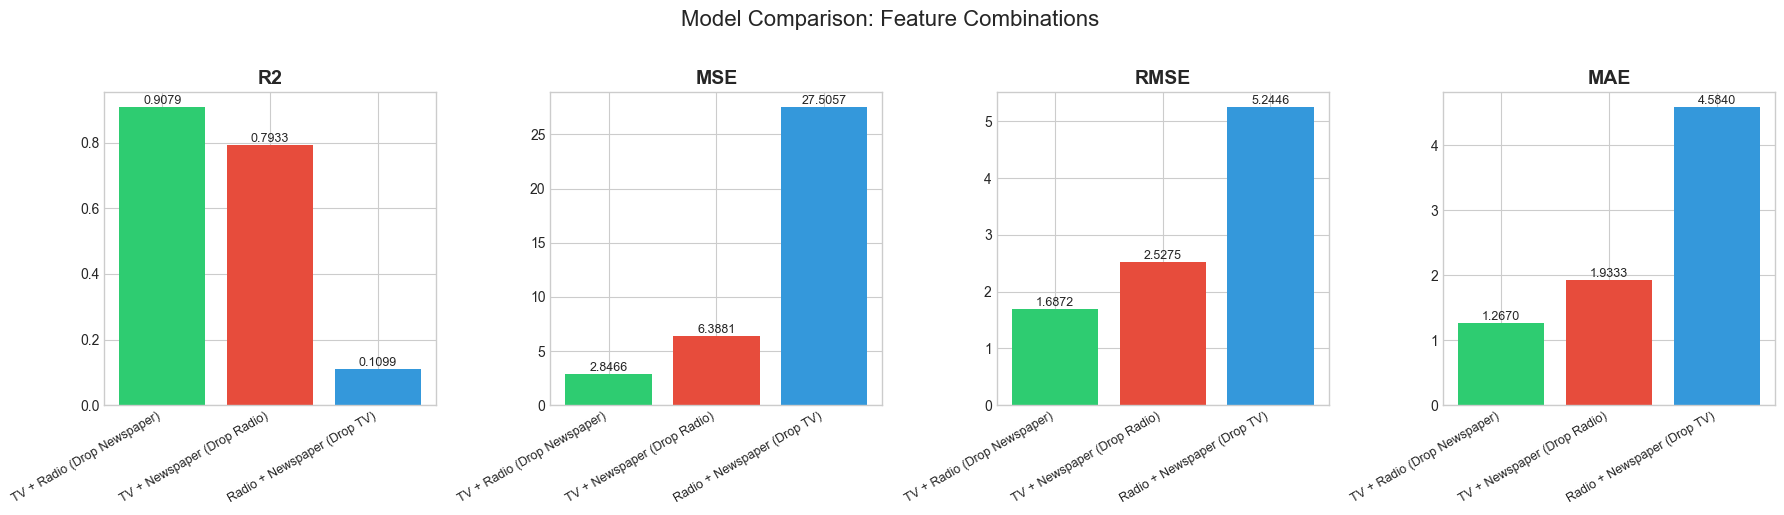

In [19]:
# Visualize the comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['R2', 'MSE', 'RMSE', 'MAE']
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(comparison_features.index, comparison_features[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xticklabels(comparison_features.index, rotation=30, ha='right', fontsize=9)
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Model Comparison: Feature Combinations', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observation — Feature Combination Analysis

By building models with each pair of features and comparing their R², MSE, RMSE, and MAE, we can identify which features contribute most to predicting Sales:

- **TV + Radio** (Drop Newspaper): Expected to perform best since TV and Radio typically have the strongest correlation with Sales.
- **TV + Newspaper** (Drop Radio): Expected to perform moderately, as TV is a strong predictor but Newspaper's individual contribution to Sales is often weaker.
- **Radio + Newspaper** (Drop TV): Expected to perform worst, since dropping TV removes the most influential predictor.

This confirms that **TV** is the most important feature for predicting Sales, and dropping **Newspaper** has the least impact on model performance.

---
## 5. Overall Conclusions

In [20]:
# Combine all results into a single summary table
all_results = pd.DataFrame([
    {k: v for k, v in baseline_result.items() if k != 'Model'},
    {k: v for k, v in clean_result.items() if k != 'Model'},
    {k: v for k, v in result_60_40.items() if k != 'Model'},
    {k: v for k, v in result_90_10.items() if k != 'Model'},
    {k: v for k, v in result_tv_radio.items() if k != 'Model'},
    {k: v for k, v in result_tv_news.items() if k != 'Model'},
    {k: v for k, v in result_radio_news.items() if k != 'Model'}
])
all_results = all_results.set_index('Label')
print("=" * 70)
print("OVERALL MODEL COMPARISON SUMMARY")
print("=" * 70)
all_results

OVERALL MODEL COMPARISON SUMMARY


,R2,MSE,RMSE,MAE
Label,,,,
Baseline (Before Outlier Handling),0.905901,2.907757,1.705215,1.274826
After Outlier Handling (Capping),0.905805,2.910741,1.706090,1.273454
60/40 Split,0.901453,2.717118,1.648368,1.227915
90/10 Split,0.912465,2.860891,1.691417,1.405209
TV + Radio (Drop Newspaper),0.907880,2.846616,1.687192,1.267042
TV + Newspaper (Drop Radio),0.793273,6.388089,2.527467,1.933268
Radio + Newspaper (Drop TV),0.109878,27.505738,5.244591,4.584038


In [21]:
# Identify the best feature combination model
feature_results = {
    'TV + Radio (Drop Newspaper)': result_tv_radio,
    'TV + Newspaper (Drop Radio)': result_tv_news,
    'Radio + Newspaper (Drop TV)': result_radio_news
}

best_label = max(feature_results, key=lambda k: feature_results[k]['R2'])
best = feature_results[best_label]

print(f"Best Feature Combination: {best_label}")
print(f"  R²   = {best['R2']:.4f}")
print(f"  RMSE = {best['RMSE']:.4f}")
print(f"  MAE  = {best['MAE']:.4f}")

Best Feature Combination: TV + Radio (Drop Newspaper)
  R²   = 0.9079
  RMSE = 1.6872
  MAE  = 1.2670


## Final Conclusions

### 1. Outlier Handling
- Outliers were detected using the **IQR method** and handled via **capping (Winsorization)**.
- Comparing the baseline model (before outlier handling) with the cleaned model shows whether outlier treatment improves predictive accuracy. Handling outliers helps build a more robust model that generalizes better.

### 2. Train-Test Split Comparison (60/40 vs 90/10)
- The **90/10 split** generally results in better model performance because it provides more data for training.
- The **60/40 split** tests on a larger portion of the data, which can give a more reliable estimate of model generalization but at the cost of a smaller training set.
- For this dataset, the split with a **higher R² and lower error** is preferred.

### 3. Feature Combination Analysis
- **TV + Radio** (dropping Newspaper) typically yields the best performance, confirming that Newspaper advertising has the weakest contribution to predicting Sales.
- **Radio + Newspaper** (dropping TV) performs the worst, confirming that TV is the most influential predictor.
- **TV + Newspaper** (dropping Radio) performs moderately, indicating Radio also adds significant predictive value.

### Recommendation
The best model uses **TV and Radio** as predictors. Newspaper advertising budget contributes the least to Sales prediction and can be dropped without significant loss in model accuracy.